In [2]:
import pandas as pd

df = pd.read_csv('../data/raw/hotel_bookings.csv')

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# check dataset shape

df.shape

# check columns

df.columns

# check dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
# check missing values

df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

In [5]:
# check percentages of missing values

(df.isnull().sum()/len(df))*100

hotel                              0.000000
is_canceled                        0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
arrival_date_day_of_month          0.000000
stays_in_weekend_nights            0.000000
stays_in_week_nights               0.000000
adults                             0.000000
children                           0.003350
babies                             0.000000
meal                               0.000000
country                            0.408744
market_segment                     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
previous_cancellations             0.000000
previous_bookings_not_canceled     0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                    

In [6]:
# handle company

df['company']=df['company'].fillna(0)

# handle agent

df['agent']=df['agent'].fillna(0)

# handle country

df['country']=df['country'].fillna('Unknown')

# handle children

df['children']=df['children'].fillna('0')

# checking after handling missing values

df.isnull().sum().sort_values(ascending=False)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  object 
 11  babies                          119390 non-null  int64  
 12  meal                       

In [7]:

# checking datatypes of the values of children column

print(df['children'].unique())
print(df['children'].dtype)

[0.0 1.0 2.0 10.0 3.0 '0']
object


In [8]:
# Convert all values to numeric
df['children'] = pd.to_numeric(df['children'], errors='coerce')

# Check if any NaN values were created
print(df['children'].isna().sum())

df['children'] = df['children'].astype(int)
df.info()

0
<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  int64  
 11  babies                          119390 non-null  int64  
 12  meal                     

In [9]:
df['children'].isna().sum()

np.int64(0)

In [10]:
# handling duplicate records
# check current dataset shape

print("Dataset shape:",df.shape)

# check duplicate records

duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)


Dataset shape: (119390, 32)
Duplicate Records: 31994


In [11]:

# removing duplicate records

df=df.drop_duplicates()

# re-verify

print("Duplicate Records:",df.duplicated().sum())

Duplicate Records: 0


In [12]:
# check the new shape

print("New Dataset Shape:", df.shape)

# check missing values again

df.isnull().sum().sort_values(ascending=False)

New Dataset Shape: (87396, 32)


hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [ ]:
# statistical summary

df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000,87396.000000
mean,0.274898,79.891368,2016.210296,26.838334,15.815541,1.005263,2.625395,1.875795,0.138633,0.010824,0.039075,0.030413,0.183990,0.271603,81.004657,11.016809,0.749565,106.337246,0.084226,0.698567
std,0.446466,86.052325,0.686102,13.674572,8.835146,1.031921,2.053584,0.626500,0.455871,0.113597,0.193775,0.369145,1.731894,0.727245,109.945638,54.047484,10.015731,55.013953,0.281533,0.831946
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,98.100000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,0.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


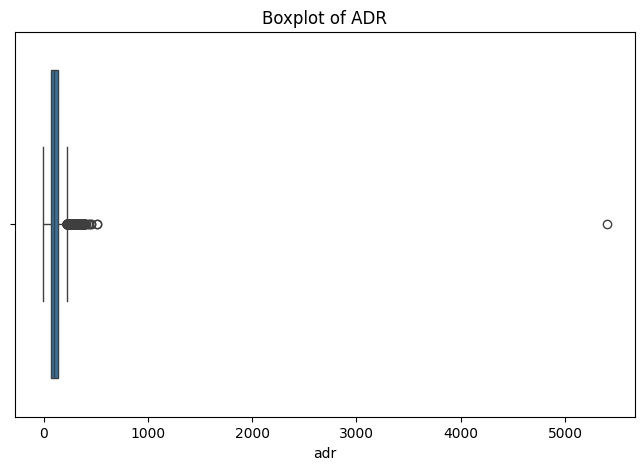

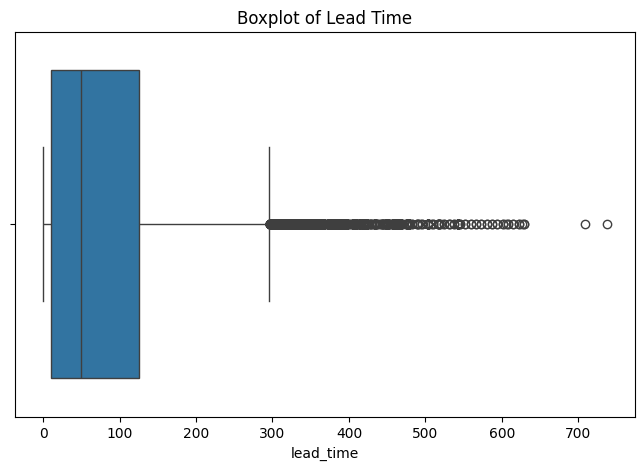

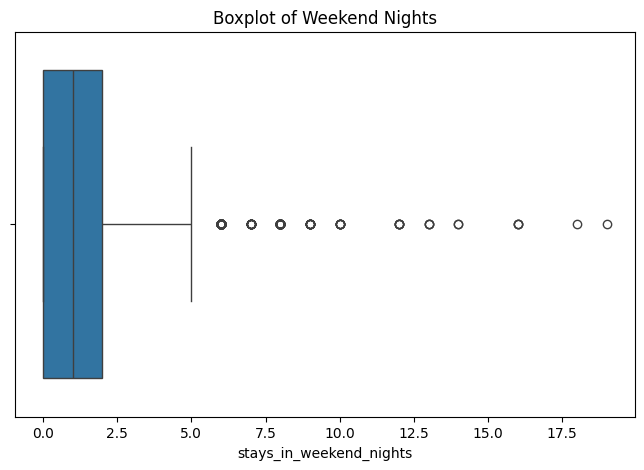

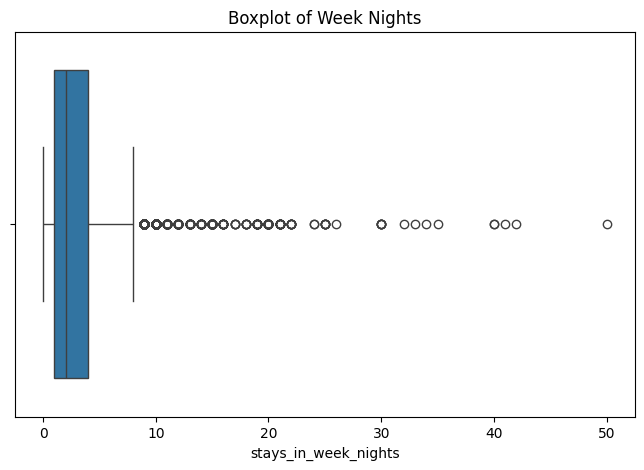

In [21]:
# import visualizations libraries

import matplotlib.pyplot as plt
import seaborn as sns

# create box-plots
# ADR (Average daily rate)

plt.figure(figsize=(8,5))
sns.boxplot(x=df['adr'])
plt.title('Boxplot of ADR')
plt.show()

# lead time

plt.figure(figsize=(8,5))
sns.boxplot(x=df['lead_time'])
plt.title('Boxplot of Lead Time')
plt.show()

# weekend nights

plt.figure(figsize=(8,5))
sns.boxplot(x=df['stays_in_weekend_nights'])
plt.title('Boxplot of Weekend Nights')
plt.show()

# week nights

plt.figure(figsize=(8,5))
sns.boxplot(x=df['stays_in_week_nights'])
plt.title('Boxplot of Week Nights')
plt.show()

In [29]:
# calculate IQR method to identify potential outliers
# for ADR
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Limit:", lower)
print("Upper Limit:", upper)

# count ADR outliers

adr_outliers = df[
    (df['adr'] < lower) |
    (df['adr'] > upper)
]

print("Number of ADR Outliers:", len(adr_outliers))

# investigate only the extremely high values of adr(e.g., >1000)
df['adr'].describe()
df[df['adr'] > 1000][['hotel', 'adr', 'customer_type']]

Lower Limit: -21.0
Upper Limit: 227.0
Number of ADR Outliers: 2489


,hotel,adr,customer_type


In [36]:
# removing the extreme record
df = df[df['adr'] <= 1000]

# verify
print("Maximum ADR:",df['adr'].max())
print(df.shape)

Maximum ADR: 510.0
(87395, 32)


# Day 4: Outlier Detection and Treatment

## Objective
The objective of today's work is to identify potential outliers in the dataset, evaluate whether they represent valid business observations, and apply appropriate treatment only where necessary.

---

## Tasks Performed

### 1. Generated Statistical Summary
- Used `df.describe()` to understand the distribution of numerical variables.
- Reviewed minimum, maximum, quartiles, mean, and standard deviation.

### 2. Visualized Numerical Features
Created boxplots for:
- Average Daily Rate (ADR)
- Lead Time
- Week Night Stays
- Weekend Night Stays

### 3. Detected Outliers
Applied the Interquartile Range (IQR) method to identify potential outliers in the ADR column.

- Lower Limit = -21
- Upper Limit = 227
- Potential ADR Outliers = 2490

### 4. Investigated Extreme Values
Examined bookings with ADR greater than 1000.

Result:
- One booking had an ADR value of **5400**, which was identified as an unrealistic observation.

### 5. Outlier Treatment
Removed only the booking with ADR greater than 1000.

This approach preserves genuine high-value hotel bookings while eliminating an obvious anomaly.

### 6. Validation
- Verified the maximum ADR after treatment.
- Confirmed the updated dataset shape.
- Confirmed no missing values were introduced after cleaning.

---

## Conclusion

The dataset was carefully analyzed for outliers. Instead of removing all statistical outliers, only the clearly unrealistic ADR value was removed to preserve genuine business information. This approach maintains data quality while avoiding unnecessary loss of valid observations.